# master_15_07_v2 -> Single-task (4 model riêng biệt)

Bản này tách model multi-task (1 model dùng chung cho cả 4 tiêu chí) thành **4 model đơn nhiệm**,
mỗi model chỉ train và tối ưu cho **đúng 1 tiêu chí**:

1. Food quality
2. Price
3. Service quality
4. Atmosphere

Mỗi phần bên dưới (Phần 1-4) đều tự in ra: biểu đồ Loss/F1/Score theo epoch, ma trận nhầm lẫn
(số lượng + %), classification report, và lưu checkpoint/report riêng cho từng tiêu chí.

Phần 0 là code dùng chung (bắt buộc chạy trước). Phần 5 tổng hợp so sánh 4 model để trả lời câu hỏi
của thầy: **model nào cho accuracy cao nhất, và cao nhất là bao nhiêu.**

Yêu cầu: đặt file `labeled_results_all_v2.json` cùng thư mục làm việc.


## Phần 0 - Code dùng chung (Config, Model, Dataset, Loss, Train/Eval loop)
Chạy cell này trước, chỉ cần chạy 1 lần.

In [ ]:
from __future__ import annotations

import copy
import json
import warnings
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, f1_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.optim import AdamW
from torch.optim.lr_scheduler import SequentialLR
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from tqdm import tqdm
from transformers import AutoModel, AutoTokenizer, get_cosine_schedule_with_warmup

warnings.filterwarnings("ignore")

CLASS_NAMES = ["Negative", "Neutral", "Positive"]


@dataclass
class SingleAspectConfig:
    aspect: str
    model_name: str = "vinai/phobert-base-v2"
    data_file: str = "labeled_results_all_v2.json"
    output_dir: str = "."
    seed: int = 42
    max_len: int = 256
    batch_size: int = 64
    epochs: int = 15
    max_lr: float = 1.5e-5
    weight_decay: float = 0.1
    layer_decay: float = 0.9
    warmup_ratio: float = 0.1
    num_workers: int = 0
    label_smoothing: float = 0.08

    # ===== Model regularization =====
    dropout_projection: float = 0.35
    dropout_multisample: Tuple[float, float, float] = (0.15, 0.25, 0.35)
    hidden_projection_size: int = 256

    # ===== Sampler / class weight =====
    sampler_clip_min: float = 0.25
    sampler_clip_max: float = 4.0
    negative_boost: float = 1.0  # bơm thêm trọng số class Negative nếu cần

    # ===== Loss =====
    use_focal: bool = True
    focal_gamma: float = 2.0
    use_margin_loss: bool = False
    margin_threshold: float = 1.0
    margin_loss_weight: float = 0.0

    # ===== R-Drop-lite =====
    rdrop_alpha: float = 0.6
    rdrop_warmup_epochs: int = 1

    # ===== LR warm-restart =====
    warm_restart_epoch: int = 10
    restart_warmup_ratio: float = 0.08

    # ===== EMA =====
    use_ema: bool = True
    ema_decay: float = 0.999
    ema_start_epoch: int = 3

    # ===== Output file names (tự sinh theo aspect nếu để trống) =====
    checkpoint_name: str = ""
    report_name: str = ""
    confusion_name: str = ""
    history_name: str = ""

    def __post_init__(self):
        slug = self.aspect.lower().replace(" ", "_")
        if not self.checkpoint_name:
            self.checkpoint_name = f"best_{slug}_single.pth"
        if not self.report_name:
            self.report_name = f"{slug}_single_report.json"
        if not self.confusion_name:
            self.confusion_name = f"{slug}_single_confusion.png"
        if not self.history_name:
            self.history_name = f"{slug}_single_history.png"


def set_seed(seed: int) -> None:
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def map_label(value: float) -> int:
    if value == 0.0:
        return 0
    if value == 0.5:
        return 1
    if value == 1.0:
        return 2
    return 1


def find_data_file(data_file: str) -> Path:
    base_dir = Path.cwd()
    candidates = [base_dir / data_file, base_dir.parent / data_file, Path(data_file)]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Cannot find data file: {data_file}")


def load_dataframe_single(data_path: Path, aspect: str) -> pd.DataFrame:
    """Chỉ lấy các mẫu CÓ nhãn cho đúng khía cạnh này (bỏ mẫu thiếu nhãn thay vì gán mặc định Neutral)."""
    with data_path.open("r", encoding="utf-8") as f:
        raw_data = json.load(f)

    rows: List[Dict] = []
    for item in raw_data:
        label_value = None
        for entry in item["labels"]:
            if entry["name"] == aspect:
                label_value = entry["value"]
                break
        if label_value is None:
            continue
        rows.append({"text": item["original_data"]["textTranslated"], "label": map_label(label_value)})

    return pd.DataFrame(rows)


def safe_split(df: pd.DataFrame, seed: int) -> Tuple[pd.DataFrame, pd.DataFrame]:
    stratify_key = df["label"].astype(str)
    train_df, val_df = train_test_split(df, test_size=0.2, random_state=seed, stratify=stratify_key)
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True)


class SingleAspectDataset(Dataset):
    def __init__(self, df: pd.DataFrame, tokenizer: AutoTokenizer, max_len: int):
        self.texts = df["text"].values
        self.labels = df["label"].values
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, index: int) -> Dict[str, torch.Tensor]:
        encoding = self.tokenizer(
            str(self.texts[index]),
            add_special_tokens=True,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt",
        )
        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "labels": torch.tensor(self.labels[index], dtype=torch.long),
        }


# ================== FOCAL LOSS ==================
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.0):
        super().__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(weight=weight, label_smoothing=label_smoothing, reduction="none")

    def forward(self, input, target):
        ce_loss = self.ce(input, target)
        pt = torch.exp(-ce_loss)
        return (((1 - pt) ** self.gamma) * ce_loss).mean()


# ================== MARGIN LOSS NEGATIVE-NEUTRAL ==================
class NegativeNeutralMarginLoss(nn.Module):
    """Với mẫu Negative thật, ép logit(Negative) - logit(Neutral) >= margin."""

    def __init__(self, margin: float = 1.0):
        super().__init__()
        self.margin = margin

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        neg_mask = targets == 0
        if neg_mask.sum() == 0:
            return logits.new_tensor(0.0)
        violation = F.relu(self.margin - (logits[neg_mask, 0] - logits[neg_mask, 1]))
        return violation.mean()


# ================== MODEL: SINGLE-ASPECT PHOBERT ==================
class SingleAspectPhoBERT(nn.Module):
    def __init__(self, model_name: str, n_classes: int = 3, hidden_projection_size: int = 256,
                 dropout_projection: float = 0.35, dropout_multisample: Tuple[float, float, float] = (0.15, 0.25, 0.35)):
        super().__init__()
        self.phobert = AutoModel.from_pretrained(model_name)
        hidden_size = self.phobert.config.hidden_size

        self.attention = nn.Sequential(nn.Linear(hidden_size, hidden_size), nn.Tanh(), nn.Linear(hidden_size, 1))
        self.projection = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_projection_size),
            nn.LayerNorm(hidden_projection_size),
            nn.GELU(),
            nn.Dropout(dropout_projection),
        )
        self.dropouts = nn.ModuleList([nn.Dropout(p=p) for p in dropout_multisample])
        self.classifier = nn.Linear(hidden_projection_size, n_classes)

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor, return_views: bool = False):
        outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden = outputs.last_hidden_state
        cls_pooled = last_hidden[:, 0, :]
        mask = attention_mask.unsqueeze(-1).float()

        attn_weights = self.attention(last_hidden)
        attn_weights = attn_weights.masked_fill(mask == 0, torch.finfo(attn_weights.dtype).min)
        attn_weights = F.softmax(attn_weights, dim=1)
        aspect_pooled = torch.sum(attn_weights * last_hidden, dim=1)

        fused = torch.cat([cls_pooled, aspect_pooled], dim=-1)
        aspect_repr = self.projection(fused)

        stacked = torch.stack([self.classifier(drop(aspect_repr)) for drop in self.dropouts], dim=0)
        logits = stacked.mean(dim=0)
        if return_views:
            return logits, stacked
        return logits


# ================== R-DROP-LITE ==================
def rdrop_consistency_loss(view_logits: torch.Tensor) -> torch.Tensor:
    n_views = view_logits.size(0)
    if n_views < 2:
        return view_logits.new_tensor(0.0)
    log_probs = F.log_softmax(view_logits, dim=-1)
    probs = log_probs.exp()
    loss = view_logits.new_tensor(0.0)
    pairs = 0
    for i in range(n_views):
        for j in range(n_views):
            if i == j:
                continue
            loss = loss + F.kl_div(log_probs[i], probs[j], reduction="batchmean")
            pairs += 1
    return loss / max(pairs, 1)


# ================== EMA ==================
class ModelEma:
    def __init__(self, model: nn.Module, decay: float = 0.999, device: Optional[torch.device] = None):
        self.decay = decay
        self.module = copy.deepcopy(model)
        self.module.eval()
        if device is not None:
            self.module.to(device)
        for p in self.module.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model: nn.Module) -> None:
        msd = model.state_dict()
        for k, v in self.module.state_dict().items():
            model_v = msd[k].detach()
            if v.dtype.is_floating_point:
                v.copy_(v * self.decay + (1.0 - self.decay) * model_v)
            else:
                v.copy_(model_v)


def build_class_weights(train_df: pd.DataFrame, config: SingleAspectConfig, device: torch.device) -> torch.Tensor:
    classes = np.unique(train_df["label"].values)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=train_df["label"].values)
    weights = np.sqrt(weights)  # softening
    if config.negative_boost != 1.0:
        weights[0] *= config.negative_boost
    weights = np.clip(weights, config.sampler_clip_min, config.sampler_clip_max)
    return torch.tensor(weights, dtype=torch.float32, device=device)


def build_sample_weights(train_df: pd.DataFrame, class_weights: torch.Tensor, config: SingleAspectConfig) -> np.ndarray:
    weights_np = class_weights.detach().cpu().numpy()
    sample_weights = weights_np[train_df["label"].values.astype(int)]
    return np.clip(sample_weights, config.sampler_clip_min, config.sampler_clip_max)


def build_optimizer(model: SingleAspectPhoBERT, config: SingleAspectConfig) -> AdamW:
    no_decay = ["bias", "LayerNorm.weight"]
    param_groups = []

    head_params = list(model.classifier.parameters()) + list(model.projection.parameters()) + list(model.attention.parameters())
    param_groups.append({"params": head_params, "lr": config.max_lr})

    if hasattr(model.phobert, "encoder") and hasattr(model.phobert.encoder, "layer"):
        n_layers = len(model.phobert.encoder.layer)
        for layer_idx in range(n_layers - 1, -1, -1):
            layer_lr = config.max_lr * (config.layer_decay ** (n_layers - layer_idx))
            layer = model.phobert.encoder.layer[layer_idx]
            decay_params = [p for n, p in layer.named_parameters() if not any(nd in n for nd in no_decay)]
            nodecay_params = [p for n, p in layer.named_parameters() if any(nd in n for nd in no_decay)]
            if decay_params:
                param_groups.append({"params": decay_params, "weight_decay": config.weight_decay, "lr": layer_lr})
            if nodecay_params:
                param_groups.append({"params": nodecay_params, "weight_decay": 0.0, "lr": layer_lr})

    if hasattr(model.phobert, "embeddings"):
        embed_lr = config.max_lr * (config.layer_decay ** (n_layers + 1))
        decay_params = [p for n, p in model.phobert.embeddings.named_parameters() if not any(nd in n for nd in no_decay)]
        nodecay_params = [p for n, p in model.phobert.embeddings.named_parameters() if any(nd in n for nd in no_decay)]
        if decay_params:
            param_groups.append({"params": decay_params, "weight_decay": config.weight_decay, "lr": embed_lr})
        if nodecay_params:
            param_groups.append({"params": nodecay_params, "weight_decay": 0.0, "lr": embed_lr})

    return AdamW(param_groups)


def build_scheduler(optimizer: AdamW, config: SingleAspectConfig, steps_per_epoch: int):
    total_steps = steps_per_epoch * config.epochs
    restart_epoch = config.warm_restart_epoch

    if 0 < restart_epoch < config.epochs:
        phase1_steps = steps_per_epoch * restart_epoch
        phase2_steps = total_steps - phase1_steps
        warmup1 = max(1, int(phase1_steps * config.warmup_ratio))
        warmup2 = max(1, int(phase2_steps * config.restart_warmup_ratio))

        scheduler_phase1 = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=warmup1, num_training_steps=phase1_steps)
        scheduler_phase2 = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=warmup2, num_training_steps=phase2_steps)
        return SequentialLR(optimizer, schedulers=[scheduler_phase1, scheduler_phase2], milestones=[phase1_steps])

    warmup_steps = int(total_steps * config.warmup_ratio)
    return get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)


def make_loss_fn(class_weights: torch.Tensor, config: SingleAspectConfig, device: torch.device):
    if config.use_focal:
        loss_fn = FocalLoss(weight=class_weights, gamma=config.focal_gamma, label_smoothing=config.label_smoothing).to(device)
    else:
        loss_fn = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=config.label_smoothing).to(device)
    margin_fn = NegativeNeutralMarginLoss(margin=config.margin_threshold).to(device) if config.use_margin_loss else None
    return loss_fn, margin_fn


def compute_batch_loss(logits, view_logits, labels, loss_fn, margin_fn, config: SingleAspectConfig, apply_rdrop: bool):
    loss = loss_fn(logits, labels)
    if margin_fn is not None:
        loss = loss + config.margin_loss_weight * margin_fn(logits, labels)
    if apply_rdrop and view_logits is not None:
        loss = loss + config.rdrop_alpha * rdrop_consistency_loss(view_logits)
    return loss


@torch.no_grad()
def evaluate(model, data_loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_targets = [], []

    for batch in tqdm(data_loader, desc="Validation", leave=False):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        with torch.amp.autocast(device_type="cuda", enabled=device.type == "cuda"):
            logits = model(input_ids, attention_mask)
            loss = loss_fn(logits, labels)

        total_loss += float(loss.item())
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().tolist())
        all_targets.extend(labels.cpu().tolist())

    preds_arr, targets_arr = np.array(all_preds), np.array(all_targets)
    cm = confusion_matrix(targets_arr, preds_arr, labels=[0, 1, 2])
    per_class_recall = np.diag(cm) / np.clip(cm.sum(axis=1), 1, None)
    accuracy = float((preds_arr == targets_arr).mean())
    macro_f1 = float(f1_score(targets_arr, preds_arr, average="macro", zero_division=0))
    worst_recall = float(per_class_recall.min())
    score = 0.7 * macro_f1 + 0.3 * worst_recall

    return {
        "loss": total_loss / max(len(data_loader), 1),
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "per_class_recall": per_class_recall.tolist(),
        "worst_class_recall": worst_recall,
        "score": score,
        "confusion": cm,
        "all_preds": all_preds,
        "all_targets": all_targets,
    }


def train_one_epoch(model, data_loader, loss_fn, margin_fn, config, optimizer, scheduler, scaler, device, apply_rdrop, ema):
    model.train()
    total_loss = 0.0
    all_preds, all_targets = [], []

    for batch in tqdm(data_loader, desc="Training"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type="cuda", enabled=device.type == "cuda"):
            logits, view_logits = model(input_ids, attention_mask, return_views=True)
            loss = compute_batch_loss(logits, view_logits, labels, loss_fn, margin_fn, config, apply_rdrop)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        if ema is not None:
            ema.update(model)

        total_loss += float(loss.item())
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().tolist())
        all_targets.extend(labels.detach().cpu().tolist())

    preds_arr, targets_arr = np.array(all_preds), np.array(all_targets)
    return {
        "loss": total_loss / max(len(data_loader), 1),
        "accuracy": float((preds_arr == targets_arr).mean()),
        "macro_f1": float(f1_score(targets_arr, preds_arr, average="macro", zero_division=0)),
    }


def plot_history_single(history: Dict[str, list], aspect: str, output_path: Path) -> None:
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    axes[0].plot(epochs, history["train_loss"], label="Train Loss", marker="o")
    axes[0].plot(epochs, history["val_loss"], label="Val Loss", marker="s")
    axes[0].set_title(f"{aspect} - Loss theo Epoch")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
    axes[0].grid(True, linestyle="--", alpha=0.6)

    axes[1].plot(epochs, history["train_macro_f1"], label="Train Macro F1", marker="o")
    axes[1].plot(epochs, history["val_macro_f1"], label="Val Macro F1", marker="s")
    axes[1].set_title(f"{aspect} - Macro F1 theo Epoch")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("F1"); axes[1].legend()
    axes[1].grid(True, linestyle="--", alpha=0.6)

    axes[2].plot(epochs, history["val_score"], label="Val Score (raw)", marker="o")
    if any(v is not None for v in history["val_score_ema"]):
        ema_epochs = [e for e, v in zip(epochs, history["val_score_ema"]) if v is not None]
        ema_values = [v for v in history["val_score_ema"] if v is not None]
        axes[2].plot(ema_epochs, ema_values, label="Val Score (EMA)", marker="^")
    axes[2].axvline(x=history.get("warm_restart_epoch", -1), color="gray", linestyle=":", label="LR restart")
    axes[2].set_title(f"{aspect} - Val Score theo Epoch")
    axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Score"); axes[2].legend()
    axes[2].grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()


def plot_confusion_single(cm: np.ndarray, aspect: str, output_path: Path) -> None:
    row_sums = cm.sum(axis=1)[:, np.newaxis]
    row_sums[row_sums == 0] = 1
    cm_pct = (cm.astype(float) / row_sums) * 100

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    axes[0].set_title(f"{aspect} - Ma trận nhầm lẫn (số lượng)")
    axes[0].set_xlabel("Dự đoán"); axes[0].set_ylabel("Thực tế")

    sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[1], vmin=0, vmax=100,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cbar_kws={"label": "%"})
    axes[1].set_title(f"{aspect} - Ma trận nhầm lẫn (%)")
    axes[1].set_xlabel("Dự đoán"); axes[1].set_ylabel("Thực tế")

    plt.tight_layout()
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"\n--- {aspect}: bảng ma trận nhầm lẫn theo % ---")
    df_cm = pd.DataFrame(cm_pct, index=[f"Thực tế {c}" for c in CLASS_NAMES], columns=[f"Dự đoán {c}" for c in CLASS_NAMES])
    print(df_cm.map(lambda x: f"{x:.1f}%"))


def train_single_aspect(config: SingleAspectConfig) -> Dict:
    """Huấn luyện + đánh giá 1 model đơn nhiệm cho đúng 1 tiêu chí (single-task)."""
    set_seed(config.seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if torch.cuda.is_available():
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.benchmark = True

    output_dir = Path.cwd() / config.output_dir
    output_dir.mkdir(parents=True, exist_ok=True)

    data_path = find_data_file(config.data_file)
    print(f"\n{'='*70}\nTIÊU CHÍ: {config.aspect}\n{'='*70}")
    print(f"Using data file: {data_path} | device: {device}")

    df = load_dataframe_single(data_path, config.aspect)
    print(f"Số mẫu có nhãn hợp lệ cho '{config.aspect}': {len(df)}")
    print(df["label"].value_counts().rename(index=dict(enumerate(CLASS_NAMES))))

    train_df, val_df = safe_split(df, config.seed)

    tokenizer = AutoTokenizer.from_pretrained(config.model_name)
    train_dataset = SingleAspectDataset(train_df, tokenizer, config.max_len)
    val_dataset = SingleAspectDataset(val_df, tokenizer, config.max_len)

    class_weights = build_class_weights(train_df, config, device)
    sample_weights = build_sample_weights(train_df, class_weights, config)
    sampler = WeightedRandomSampler(weights=torch.as_tensor(sample_weights, dtype=torch.double),
                                     num_samples=len(sample_weights), replacement=True)

    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, sampler=sampler,
                               num_workers=config.num_workers, pin_memory=torch.cuda.is_available())
    val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False,
                             num_workers=config.num_workers, pin_memory=torch.cuda.is_available())

    model = SingleAspectPhoBERT(
        model_name=config.model_name,
        hidden_projection_size=config.hidden_projection_size,
        dropout_projection=config.dropout_projection,
        dropout_multisample=config.dropout_multisample,
    ).to(device)

    optimizer = build_optimizer(model, config)
    scheduler = build_scheduler(optimizer, config, steps_per_epoch=len(train_loader))
    scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())
    loss_fn, margin_fn = make_loss_fn(class_weights, config, device)

    ema = ModelEma(model, decay=config.ema_decay, device=device) if config.use_ema else None

    best_score, best_epoch, best_source = -1.0, 0, "raw"
    best_confusion, best_metrics = None, None
    best_path = output_dir / config.checkpoint_name
    report_path = output_dir / config.report_name
    confusion_path = output_dir / config.confusion_name
    history_path = output_dir / config.history_name

    history: Dict[str, list] = {
        "train_loss": [], "train_accuracy": [], "train_macro_f1": [],
        "val_loss": [], "val_accuracy": [], "val_macro_f1": [],
        "val_worst_class_recall": [], "val_score": [], "val_score_ema": [],
        "warm_restart_epoch": config.warm_restart_epoch,
    }

    for epoch in range(config.epochs):
        print(f"\nEpoch {epoch + 1}/{config.epochs} | lr={optimizer.param_groups[0]['lr']:.2e}")
        apply_rdrop = epoch >= config.rdrop_warmup_epochs

        train_metrics = train_one_epoch(model, train_loader, loss_fn, margin_fn, config,
                                         optimizer, scheduler, scaler, device, apply_rdrop, ema)
        val_metrics = evaluate(model, val_loader, loss_fn, device)

        ema_val_metrics = None
        if ema is not None and epoch + 1 >= config.ema_start_epoch:
            ema_val_metrics = evaluate(ema.module, val_loader, loss_fn, device)

        history["train_loss"].append(train_metrics["loss"])
        history["train_accuracy"].append(train_metrics["accuracy"])
        history["train_macro_f1"].append(train_metrics["macro_f1"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_accuracy"].append(val_metrics["accuracy"])
        history["val_macro_f1"].append(val_metrics["macro_f1"])
        history["val_worst_class_recall"].append(val_metrics["worst_class_recall"])
        history["val_score"].append(val_metrics["score"])
        history["val_score_ema"].append(ema_val_metrics["score"] if ema_val_metrics else None)

        print(f"Train Loss: {train_metrics['loss']:.4f} | Train Acc: {train_metrics['accuracy']:.4f} | Train F1: {train_metrics['macro_f1']:.4f}")
        print(f"Val   Loss: {val_metrics['loss']:.4f} | Val Acc: {val_metrics['accuracy']:.4f} | Val F1: {val_metrics['macro_f1']:.4f} | Val Score: {val_metrics['score']:.4f}")
        if ema_val_metrics:
            print(f"Val Score (EMA): {ema_val_metrics['score']:.4f}")

        candidate_score, candidate_source = val_metrics["score"], "raw"
        candidate_state, candidate_metrics = model.state_dict(), val_metrics
        if ema_val_metrics and ema_val_metrics["score"] > candidate_score:
            candidate_score, candidate_source = ema_val_metrics["score"], "ema"
            candidate_state, candidate_metrics = ema.module.state_dict(), ema_val_metrics

        if candidate_score > best_score:
            best_score, best_epoch, best_source = candidate_score, epoch + 1, candidate_source
            best_confusion, best_metrics = candidate_metrics["confusion"], candidate_metrics
            torch.save(candidate_state, best_path)
            print(f"Saved best checkpoint -> {best_path.name} (source={best_source}, score={best_score:.4f})")

    plot_history_single(history, config.aspect, history_path)

    final_report = {
        "aspect": config.aspect,
        "config": asdict(config),
        "data_file": str(data_path),
        "best_score": best_score,
        "best_epoch": best_epoch,
        "best_source": best_source,
        "best_accuracy": best_metrics["accuracy"],
        "best_macro_f1": best_metrics["macro_f1"],
        "best_per_class_recall": best_metrics["per_class_recall"],
        "total_epochs_run": config.epochs,
        "history": history,
    }
    with report_path.open("w", encoding="utf-8") as f:
        json.dump(final_report, f, ensure_ascii=False, indent=2)

    print(f"\n>>> KẾT QUẢ TỐT NHẤT [{config.aspect}]: epoch {best_epoch} (source={best_source})")
    print(f"    Accuracy = {best_metrics['accuracy']:.4f} | Macro F1 = {best_metrics['macro_f1']:.4f} | Score = {best_score:.4f}")
    print("\nClassification report (best checkpoint, tập validation):")
    print(classification_report(best_metrics["all_targets"], best_metrics["all_preds"],
                                 target_names=CLASS_NAMES, digits=4, zero_division=0))

    plot_confusion_single(best_confusion, config.aspect, confusion_path)

    print(f"Checkpoint: {best_path}")
    print(f"Report:     {report_path}")
    print(f"History:    {history_path}")
    print(f"Confusion:  {confusion_path}")

    return final_report


## Phần 1 - Food quality (single-task)


TIÊU CHÍ: Food quality
Using data file: /content/labeled_results_all_v6.json | device: cuda
Số mẫu có nhãn hợp lệ cho 'Food quality': 22366
label
Positive    16159
Neutral      4506
Negative     1701
Name: count, dtype: int64


config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/895k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.14M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.13M [00:00<?, ?B/s]

...

Train Loss: 0.0620 | Train Acc: 0.9813 | Train F1: 0.9819
Val   Loss: 0.2136 | Val Acc: 0.9332 | Val F1: 0.8867 | Val Score: 0.8774
Val Score (EMA): 0.8709
Saved best checkpoint -> best_food_quality_single.pth (source=raw, score=0.8774)

Epoch 14/15 | lr=5.97e-06


Training: 100%|██████████| 280/280 [03:30<00:00,  1.33it/s]


Train Loss: 0.0584 | Train Acc: 0.9832 | Train F1: 0.9839
Val   Loss: 0.2170 | Val Acc: 0.9303 | Val F1: 0.8816 | Val Score: 0.8721
Val Score (EMA): 0.8730

Epoch 15/15 | lr=1.68e-06


Training: 100%|██████████| 280/280 [03:30<00:00,  1.33it/s]


Train Loss: 0.0555 | Train Acc: 0.9865 | Train F1: 0.9868
Val   Loss: 0.2191 | Val Acc: 0.9314 | Val F1: 0.8822 | Val Score: 0.8708
Val Score (EMA): 0.8768


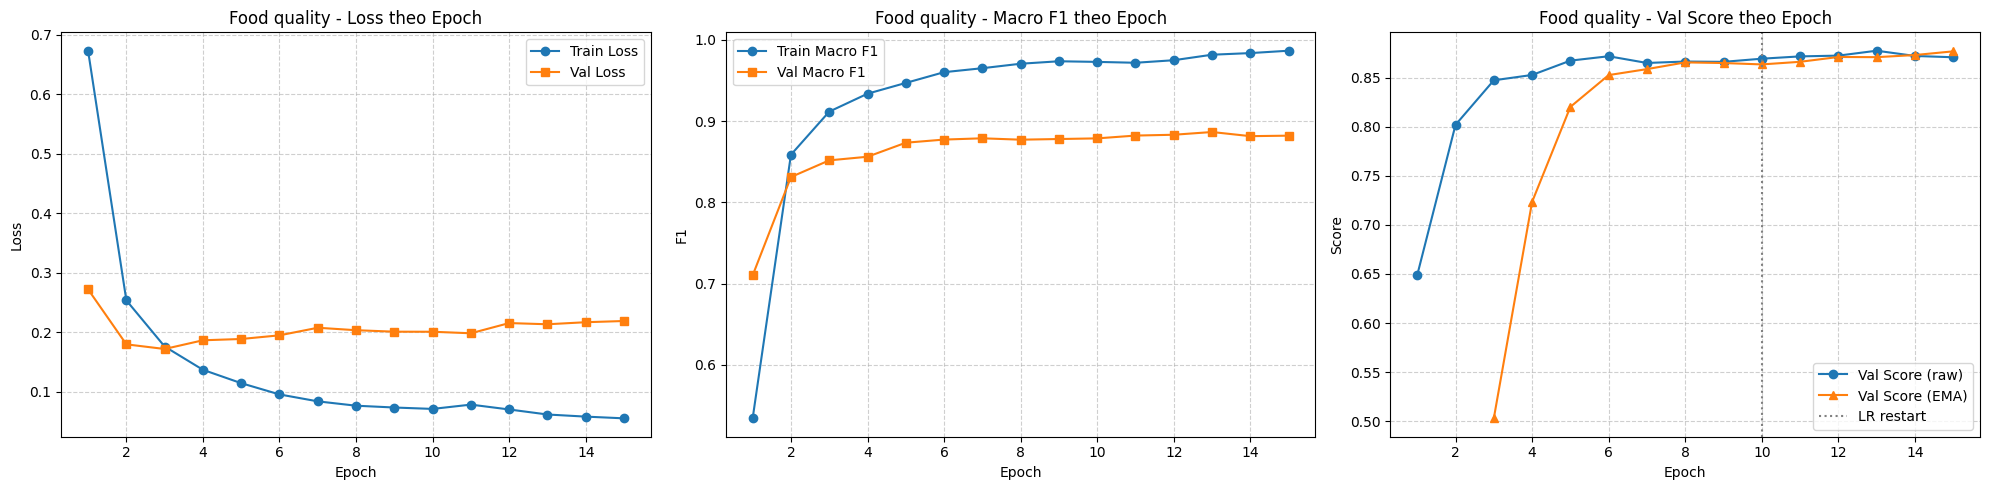


>>> KẾT QUẢ TỐT NHẤT [Food quality]: epoch 13 (source=raw)
    Accuracy = 0.9332 | Macro F1 = 0.8867 | Score = 0.8774

Classification report (best checkpoint, tập validation):
              precision    recall  f1-score   support

    Negative     0.8435    0.8559    0.8496       340
     Neutral     0.8215    0.8635    0.8420       901
    Positive     0.9761    0.9607    0.9684      3233

    accuracy                         0.9332      4474
   macro avg     0.8804    0.8934    0.8867      4474
weighted avg     0.9349    0.9332    0.9339      4474



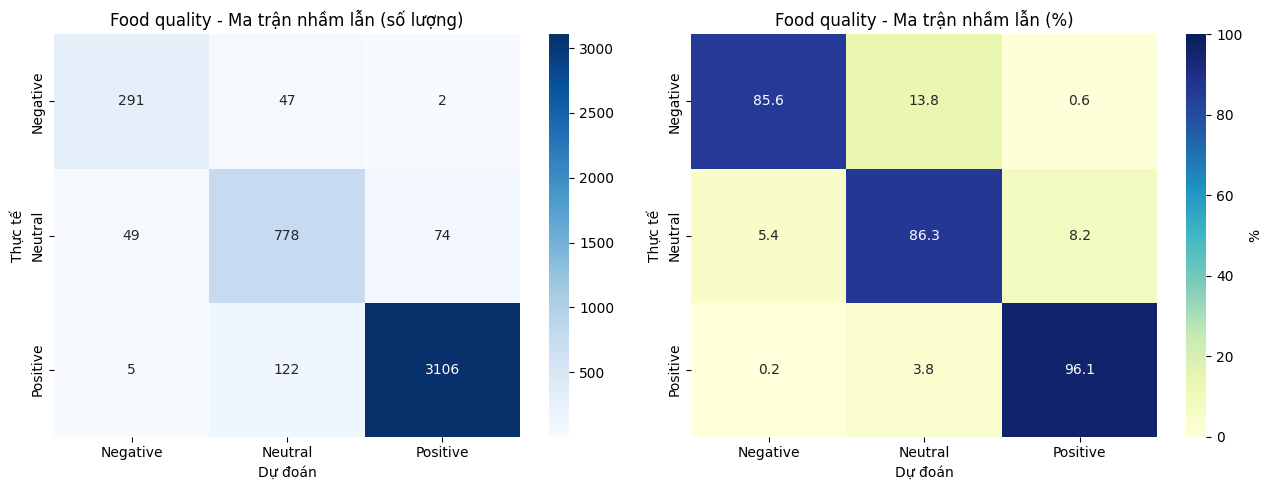


--- Food quality: bảng ma trận nhầm lẫn theo % ---
                 Dự đoán Negative Dự đoán Neutral Dự đoán Positive
Thực tế Negative            85.6%           13.8%             0.6%
Thực tế Neutral              5.4%           86.3%             8.2%
Thực tế Positive             0.2%            3.8%            96.1%
Checkpoint: /content/best_food_quality_single.pth
Report:     /content/food_quality_single_report.json
History:    /content/food_quality_single_history.png
Confusion:  /content/food_quality_single_confusion.png


In [ ]:
food_config = SingleAspectConfig(
    aspect="Food quality",
    data_file="labeled_results_all_v6.json",
    use_focal=True,
    focal_gamma=2.0,
    negative_boost=1.30,        # Food Negative chỉ 7.61%, cần bơm nhẹ
    use_margin_loss=True,
    margin_loss_weight=0.25,
)
food_report = train_single_aspect(food_config)


## Phần 2 - Price (single-task)


TIÊU CHÍ: Price
Using data file: /content/labeled_results_all_v6.json | device: cuda
Số mẫu có nhãn hợp lệ cho 'Price': 22328
label
Neutral     16149
Positive     4911
Negative     1268
Name: count, dtype: int64


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch 1/15 | lr=0.00e+00


Training: 100%|██████████| 280/280 [03:30<00:00,  1.33it/s]


...

Train Loss: 0.3292 | Train Acc: 0.9904 | Train F1: 0.9903
Val   Loss: 0.5364 | Val Acc: 0.9581 | Val F1: 0.9203 | Val Score: 0.8946
Val Score (EMA): 0.9160

Epoch 14/15 | lr=5.97e-06


Training: 100%|██████████| 280/280 [03:30<00:00,  1.33it/s]


Train Loss: 0.3233 | Train Acc: 0.9915 | Train F1: 0.9919
Val   Loss: 0.5292 | Val Acc: 0.9584 | Val F1: 0.9243 | Val Score: 0.9151
Val Score (EMA): 0.9167

Epoch 15/15 | lr=1.68e-06


Training: 100%|██████████| 280/280 [03:29<00:00,  1.33it/s]


Train Loss: 0.3180 | Train Acc: 0.9938 | Train F1: 0.9940
Val   Loss: 0.5307 | Val Acc: 0.9575 | Val F1: 0.9235 | Val Score: 0.9098
Val Score (EMA): 0.9175


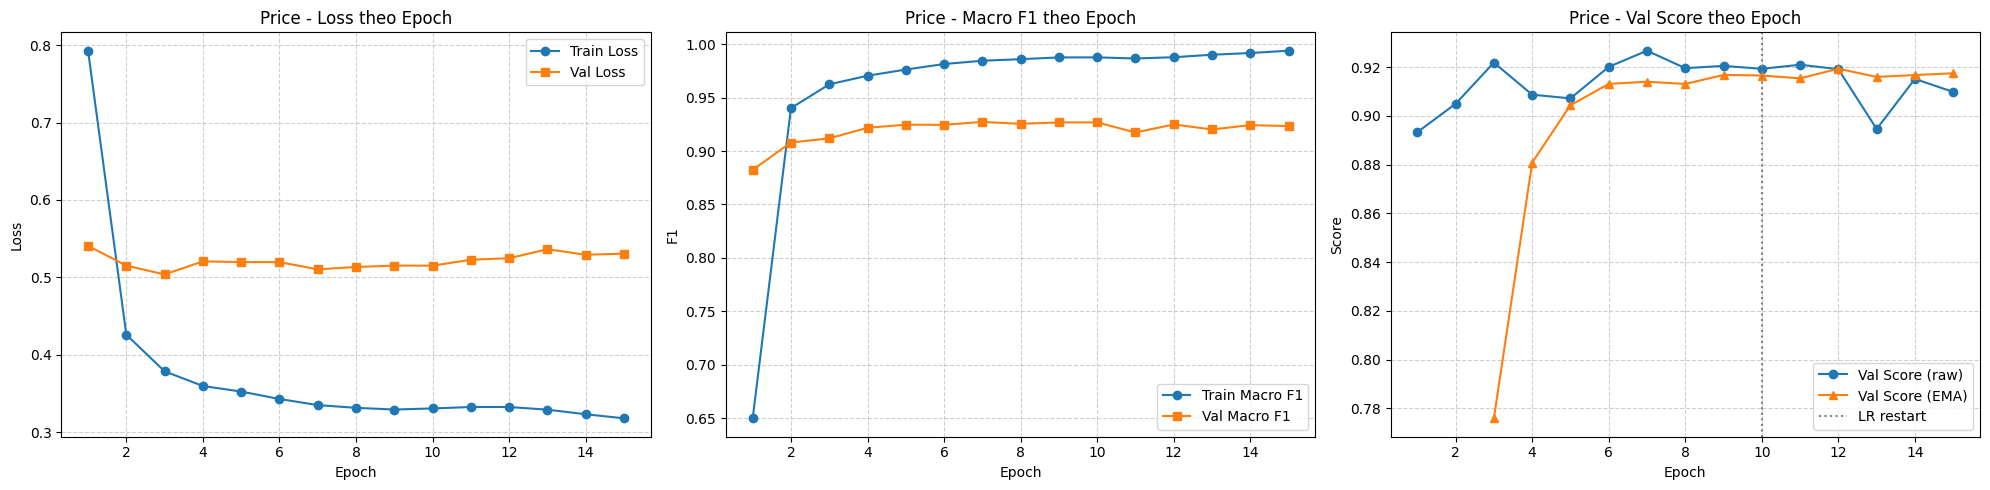


>>> KẾT QUẢ TỐT NHẤT [Price]: epoch 7 (source=raw)
    Accuracy = 0.9584 | Macro F1 = 0.9274 | Score = 0.9267

Classification report (best checkpoint, tập validation):
              precision    recall  f1-score   support

    Negative     0.8393    0.9252    0.8801       254
     Neutral     0.9800    0.9687    0.9743      3230
    Positive     0.9225    0.9328    0.9276       982

    accuracy                         0.9584      4466
   macro avg     0.9139    0.9422    0.9274      4466
weighted avg     0.9593    0.9584    0.9587      4466



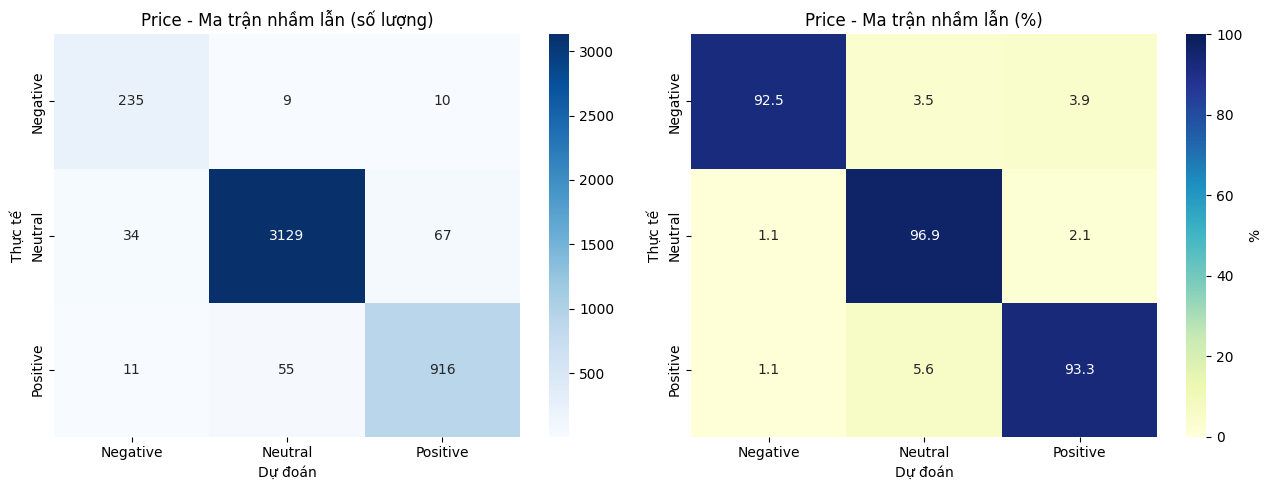


--- Price: bảng ma trận nhầm lẫn theo % ---
                 Dự đoán Negative Dự đoán Neutral Dự đoán Positive
Thực tế Negative            92.5%            3.5%             3.9%
Thực tế Neutral              1.1%           96.9%             2.1%
Thực tế Positive             1.1%            5.6%            93.3%
Checkpoint: /content/best_price_single.pth
Report:     /content/price_single_report.json
History:    /content/price_single_history.png
Confusion:  /content/price_single_confusion.png


In [4]:
price_config = SingleAspectConfig(
    aspect="Price",
    data_file="labeled_results_all_v6.json",
    use_focal=False,             # Price đã cân bằng khá tốt (Negative 5.68%, Neutral áp đảo 72.33%) -> CE thường
    negative_boost=1.10,
    use_margin_loss=False,       # không cần margin vì lỗi Negative->Neutral ở Price không nghiêm trọng
)
price_report = train_single_aspect(price_config)


## Phần 3 - Service quality (single-task)


TIÊU CHÍ: Service quality
Using data file: /content/labeled_results_all_v6.json | device: cuda
Số mẫu có nhãn hợp lệ cho 'Service quality': 22365
label
Positive    11687
Neutral      8254
Negative     2424
Name: count, dtype: int64


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch 1/15 | lr=0.00e+00


Training: 100%|██████████| 280/280 [03:30<00:00,  1.33it/s]


...

Train Loss: 0.0472 | Train Acc: 0.9849 | Train F1: 0.9858
Val   Loss: 0.1683 | Val Acc: 0.9403 | Val F1: 0.9227 | Val Score: 0.9100
Val Score (EMA): 0.9162

Epoch 14/15 | lr=5.97e-06


Training: 100%|██████████| 280/280 [03:29<00:00,  1.34it/s]


Train Loss: 0.0457 | Train Acc: 0.9867 | Train F1: 0.9875
Val   Loss: 0.1655 | Val Acc: 0.9414 | Val F1: 0.9253 | Val Score: 0.9125
Val Score (EMA): 0.9141

Epoch 15/15 | lr=1.68e-06


Training: 100%|██████████| 280/280 [03:28<00:00,  1.34it/s]


Train Loss: 0.0415 | Train Acc: 0.9909 | Train F1: 0.9914
Val   Loss: 0.1676 | Val Acc: 0.9432 | Val F1: 0.9274 | Val Score: 0.9139
Val Score (EMA): 0.9147


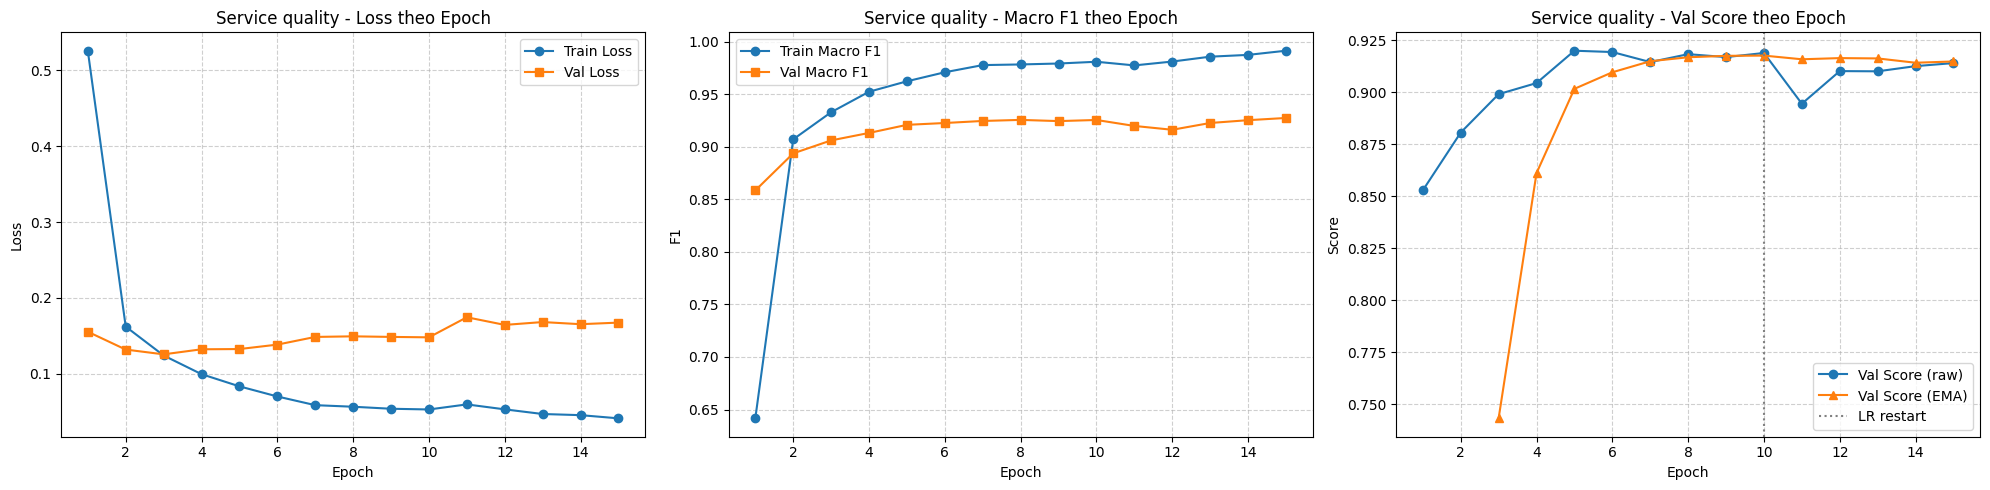


>>> KẾT QUẢ TỐT NHẤT [Service quality]: epoch 5 (source=raw)
    Accuracy = 0.9381 | Macro F1 = 0.9209 | Score = 0.9199

Classification report (best checkpoint, tập validation):
              precision    recall  f1-score   support

    Negative     0.8428    0.9175    0.8786       485
     Neutral     0.9180    0.9225    0.9202      1651
    Positive     0.9746    0.9534    0.9639      2337

    accuracy                         0.9381      4473
   macro avg     0.9118    0.9311    0.9209      4473
weighted avg     0.9394    0.9381    0.9385      4473



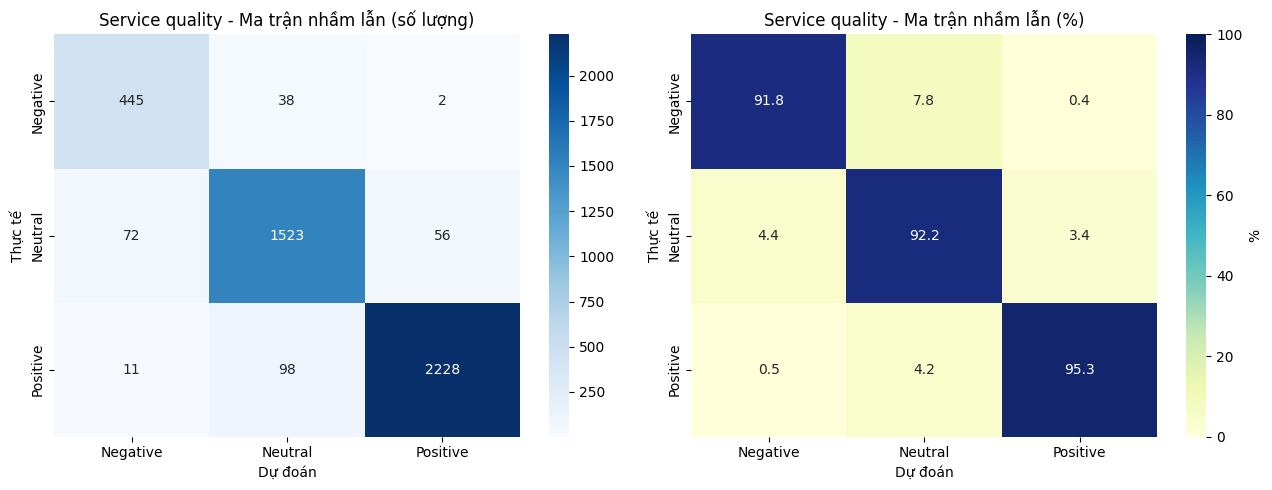


--- Service quality: bảng ma trận nhầm lẫn theo % ---
                 Dự đoán Negative Dự đoán Neutral Dự đoán Positive
Thực tế Negative            91.8%            7.8%             0.4%
Thực tế Neutral              4.4%           92.2%             3.4%
Thực tế Positive             0.5%            4.2%            95.3%
Checkpoint: /content/best_service_quality_single.pth
Report:     /content/service_quality_single_report.json
History:    /content/service_quality_single_history.png
Confusion:  /content/service_quality_single_confusion.png


In [5]:
service_config = SingleAspectConfig(
    aspect="Service quality",
    data_file="labeled_results_all_v6.json",
    use_focal=True,
    focal_gamma=2.0,
    negative_boost=1.35,        # Negative 10.84%
    use_margin_loss=True,
    margin_loss_weight=0.30,
)
service_report = train_single_aspect(service_config)


## Phần 4 - Atmosphere (single-task)


TIÊU CHÍ: Atmosphere
Using data file: /content/labeled_results_all_v6.json | device: cuda
Số mẫu có nhãn hợp lệ cho 'Atmosphere': 22358
label
Neutral     11417
Positive    10115
Negative      826
Name: count, dtype: int64


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch 1/15 | lr=0.00e+00


Training: 100%|██████████| 280/280 [03:28<00:00,  1.34it/s]


...

Train Loss: 0.0590 | Train Acc: 0.9682 | Train F1: 0.9729
Val   Loss: 0.2053 | Val Acc: 0.9065 | Val F1: 0.8428 | Val Score: 0.7991
Val Score (EMA): 0.8228

Epoch 14/15 | lr=5.97e-06


Training: 100%|██████████| 280/280 [03:29<00:00,  1.34it/s]


Train Loss: 0.0529 | Train Acc: 0.9706 | Train F1: 0.9754
Val   Loss: 0.2005 | Val Acc: 0.9052 | Val F1: 0.8419 | Val Score: 0.8002
Val Score (EMA): 0.8175

Epoch 15/15 | lr=1.68e-06


Training: 100%|██████████| 280/280 [03:29<00:00,  1.34it/s]


Train Loss: 0.0527 | Train Acc: 0.9743 | Train F1: 0.9787
Val   Loss: 0.1994 | Val Acc: 0.9108 | Val F1: 0.8508 | Val Score: 0.8083
Val Score (EMA): 0.8190


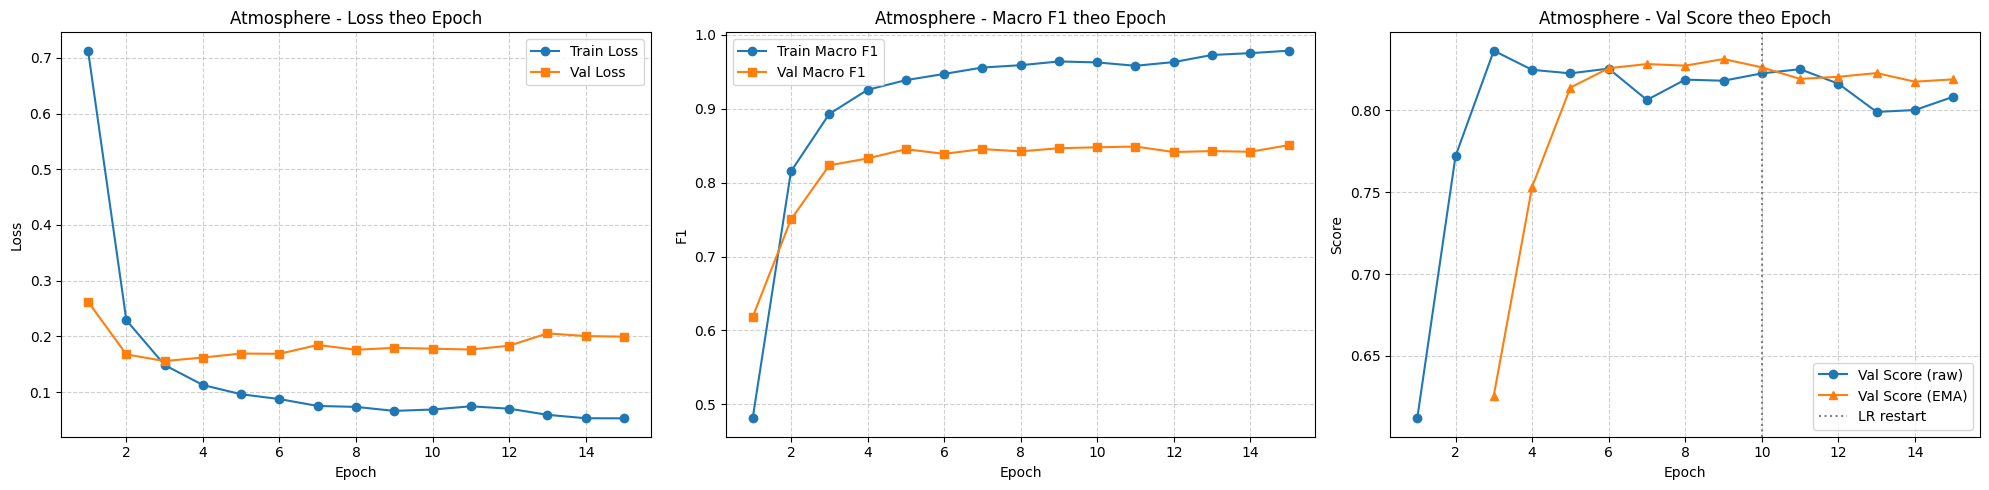


>>> KẾT QUẢ TỐT NHẤT [Atmosphere]: epoch 3 (source=raw)
    Accuracy = 0.8904 | Macro F1 = 0.8235 | Score = 0.8365

Classification report (best checkpoint, tập validation):
              precision    recall  f1-score   support

    Negative     0.5417    0.8667    0.6667       165
     Neutral     0.8964    0.9015    0.8989      2284
    Positive     0.9314    0.8799    0.9049      2023

    accuracy                         0.8904      4472
   macro avg     0.7898    0.8827    0.8235      4472
weighted avg     0.8992    0.8904    0.8931      4472



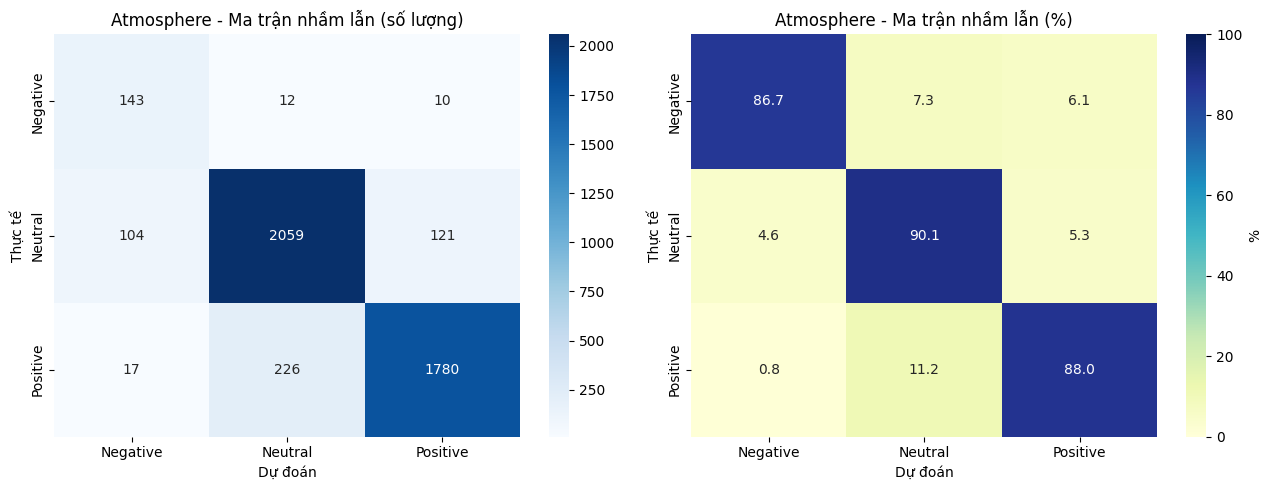


--- Atmosphere: bảng ma trận nhầm lẫn theo % ---
                 Dự đoán Negative Dự đoán Neutral Dự đoán Positive
Thực tế Negative            86.7%            7.3%             6.1%
Thực tế Neutral              4.6%           90.1%             5.3%
Thực tế Positive             0.8%           11.2%            88.0%
Checkpoint: /content/best_atmosphere_single.pth
Report:     /content/atmosphere_single_report.json
History:    /content/atmosphere_single_history.png
Confusion:  /content/atmosphere_single_confusion.png


In [6]:
atmosphere_config = SingleAspectConfig(
    aspect="Atmosphere",
    data_file="labeled_results_all_v6.json",
    use_focal=True,
    focal_gamma=2.6,             # Atmosphere khó nhất (ranh giới Negative/Neutral), gamma cao hơn
    negative_boost=1.85,         # Negative chỉ 3.69% -> cần bơm mạnh nhất trong 4 tiêu chí
    use_margin_loss=True,
    margin_loss_weight=0.60,
)
atmosphere_report = train_single_aspect(atmosphere_config)


## Phần 5 - Tổng hợp & so sánh 4 model (model nào max, accuracy max bao nhiêu)

BẢNG SO SÁNH 4 MODEL SINGLE-TASK (mỗi model chỉ train cho đúng 1 tiêu chí)
       Tiêu chí  Best epoch Nguồn Accuracy Macro F1  Score Recall Negative Recall Neutral Recall Positive
          Price           7   raw   0.9584   0.9274 0.9267          0.9252         0.9687          0.9328
Service quality           5   raw   0.9381   0.9209 0.9199          0.9175         0.9225          0.9534
   Food quality          13   raw   0.9332   0.8867 0.8774          0.8559         0.8635          0.9607
     Atmosphere           3   raw   0.8904   0.8235 0.8365          0.8667         0.9015          0.8799

>>> Model MAX (theo Accuracy): 'Price' — Accuracy = 0.9584 (Macro F1 = 0.9274, epoch 7, nguồn=raw)


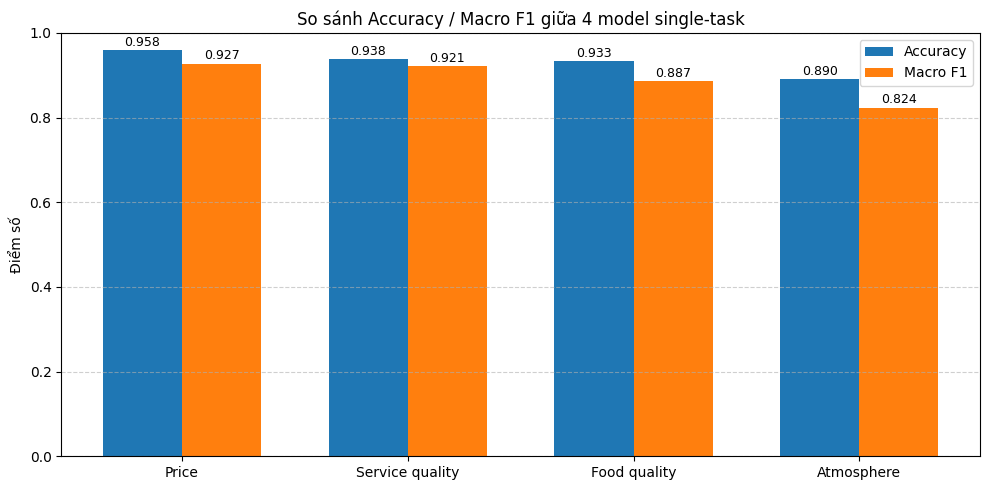


Đã lưu bảng tổng hợp: summary_4_aspects.csv
Đã lưu biểu đồ so sánh: summary_4_aspects_comparison.png


In [7]:
# ================== TỔNG HỢP & SO SÁNH 4 MODEL ĐƠN NHIỆM ==================
all_reports = {
    "Food quality": food_report,
    "Price": price_report,
    "Service quality": service_report,
    "Atmosphere": atmosphere_report,
}

summary_rows = []
for aspect, report in all_reports.items():
    summary_rows.append({
        "Tiêu chí": aspect,
        "Best epoch": report["best_epoch"],
        "Nguồn": report["best_source"],
        "Accuracy": report["best_accuracy"],
        "Macro F1": report["best_macro_f1"],
        "Score": report["best_score"],
        "Recall Negative": report["best_per_class_recall"][0],
        "Recall Neutral": report["best_per_class_recall"][1],
        "Recall Positive": report["best_per_class_recall"][2],
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Accuracy", ascending=False).reset_index(drop=True)
print("="*90)
print("BẢNG SO SÁNH 4 MODEL SINGLE-TASK (mỗi model chỉ train cho đúng 1 tiêu chí)")
print("="*90)
print(summary_df.to_string(index=False, formatters={
    "Accuracy": "{:.4f}".format, "Macro F1": "{:.4f}".format, "Score": "{:.4f}".format,
    "Recall Negative": "{:.4f}".format, "Recall Neutral": "{:.4f}".format, "Recall Positive": "{:.4f}".format,
}))

best_row = summary_df.iloc[0]
print(f"\n>>> Model MAX (theo Accuracy): '{best_row['Tiêu chí']}' — Accuracy = {best_row['Accuracy']:.4f} "
      f"(Macro F1 = {best_row['Macro F1']:.4f}, epoch {best_row['Best epoch']}, nguồn={best_row['Nguồn']})")

# Biểu đồ so sánh Accuracy / Macro F1 giữa 4 tiêu chí
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(summary_df))
width = 0.35
ax.bar(x - width/2, summary_df["Accuracy"], width, label="Accuracy")
ax.bar(x + width/2, summary_df["Macro F1"], width, label="Macro F1")
ax.set_xticks(x)
ax.set_xticklabels(summary_df["Tiêu chí"])
ax.set_ylim(0, 1)
ax.set_ylabel("Điểm số")
ax.set_title("So sánh Accuracy / Macro F1 giữa 4 model single-task")
ax.legend()
ax.grid(True, axis="y", linestyle="--", alpha=0.6)
for i, (acc, f1) in enumerate(zip(summary_df["Accuracy"], summary_df["Macro F1"])):
    ax.text(i - width/2, acc + 0.01, f"{acc:.3f}", ha="center", fontsize=9)
    ax.text(i + width/2, f1 + 0.01, f"{f1:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("summary_4_aspects_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

summary_df.to_csv("summary_4_aspects.csv", index=False)
print("\nĐã lưu bảng tổng hợp: summary_4_aspects.csv")
print("Đã lưu biểu đồ so sánh: summary_4_aspects_comparison.png")
